# 04 — Decode & durations

GMM has no decode step (`predict` is pointwise). HMM look-ahead is in Viterbi/smoothed only; filtered decode is causal.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from regime_utils import *

std_variants = {
    "full": load_full_sample_std(),
    "rolling": load_rolling_std(),
    "expanding": load_expanding_std(),
}

rows = []
for std_name, df in std_variants.items():
    X = df.values
    gmm = fit_gmm(X)
    hmm = fit_hmm(X)
    gmm_l = gmm.predict(X)
    vit = viterbi_decode(hmm, X)
    sm = smoothed_decode(hmm, X)
    filt = filtered_decode(hmm, X)
    for method, labels in [
        ("GMM pointwise", gmm_l),
        ("HMM Viterbi", vit),
        ("HMM smoothed", sm),
        ("HMM filtered", filt),
    ]:
        rows.append({
            "Std variant": std_name,
            "Method": method,
            "Mean duration (weeks)": round(run_length_mean(labels), 1),
        })

duration_table = pd.DataFrame(rows)
print(duration_table.to_string(index=False))


Std variant        Method  Mean duration (weeks)
       full GMM pointwise                    9.0
       full   HMM Viterbi                   50.5
       full  HMM smoothed                   44.7
       full  HMM filtered                   25.6
    rolling GMM pointwise                    6.2
    rolling   HMM Viterbi                   18.9
    rolling  HMM smoothed                   17.2
    rolling  HMM filtered                   13.5
  expanding GMM pointwise                    7.3
  expanding   HMM Viterbi                   26.5
  expanding  HMM smoothed                   25.6
  expanding  HMM filtered                   16.4


In [2]:

# Transition entropy (full-sample std, named states — integer IDs permute across fits)
df_full = std_variants["full"]
X = df_full.values
gmm = fit_gmm(X)
hmm = fit_hmm(X)
vix = load_raw_features().loc[df_full.index, "VIX"]
for name, ints in [
    ("GMM", gmm.predict(X)),
    ("HMM Viterbi", viterbi_decode(hmm, X)),
    ("HMM filtered", filtered_decode(hmm, X)),
]:
    named = apply_label_map(ints, label_map_from_mean_vix(ints, vix))
    ent = transition_entropy(named).reindex([CALM_LABEL, TRANSITIONAL_LABEL, STRESS_LABEL])
    print(f"{name} transition entropy (bits):\n", ent.round(3))


GMM transition entropy (bits):
 Calm            0.524
Transitional    0.618
Stressful       0.643
dtype: float64
HMM Viterbi transition entropy (bits):
 Calm            0.112
Transitional    0.121
Stressful       0.237
dtype: float64
HMM filtered transition entropy (bits):
 Calm            0.213
Transitional    0.184
Stressful       0.412
dtype: float64


In [3]:

# Cross-model ARI on integer labels (no remapping)
gmm_l = gmm.predict(X)
for decode_name, hmm_l in [("Viterbi", viterbi_decode(hmm, X)), ("filtered", filtered_decode(hmm, X))]:
    print(f"ARI GMM vs HMM {decode_name}: {cross_model_ari(gmm_l, hmm_l):.3f}")

print("\nGMM ~9 wk duration is honest (no L2 decode). HMM Viterbi ~50 wk was inflated by global smoothing.")


ARI GMM vs HMM Viterbi: 0.254
ARI GMM vs HMM filtered: 0.274

GMM ~9 wk duration is honest (no L2 decode). HMM Viterbi ~50 wk was inflated by global smoothing.


### GMM vs HMM agreement heatmap

3×3 co-classification on **named** labels (full-sample std, HMM Viterbi). Counts drive color; cell annotations show **weeks** and **row %** (share of each GMM regime). Calm/Transitional weeks scatter across off-diagonal cells; GMM Stressful weeks concentrate in the bottom-right band (half co-labeled HMM Stressful).

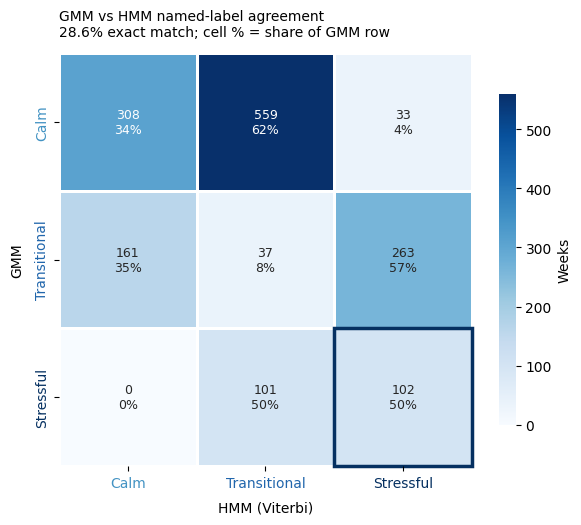

Regime_label  Calm  Transitional  Stressful
Regime_label                               
Calm           308           559         33
Transitional   161            37        263
Stressful        0           101        102

Stress–Stress: 102 wk (50% of GMM Stressful weeks)


In [4]:
import seaborn as sns

REGIME_COLORS = {
    CALM_LABEL: "#4393c3",
    TRANSITIONAL_LABEL: "#2166ac",
    STRESS_LABEL: "#053061",
}
LABEL_ORDER = [CALM_LABEL, TRANSITIONAL_LABEL, STRESS_LABEL]
FONT = {"fontsize": 10, "fontweight": "normal"}

raw = load_raw_features().loc[df_full.index]
gmm_named = build_regime_frame(raw, gmm_l, "Regime_GMM")["Regime_label"]
hmm_named = build_regime_frame(raw, viterbi_decode(hmm, X), "Regime_HMM")["Regime_label"]

counts = pd.crosstab(gmm_named, hmm_named).reindex(
    index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0
)
row_pct = counts.div(counts.sum(axis=1), axis=0) * 100
exact_agree = (gmm_named.values == hmm_named.values).mean()

annot = np.empty((3, 3), dtype=object)
for i, g in enumerate(LABEL_ORDER):
    for j, h in enumerate(LABEL_ORDER):
        annot[i, j] = f"{int(counts.iloc[i, j])}\n{row_pct.iloc[i, j]:.0f}%"

fig, ax = plt.subplots(figsize=(6.2, 5.2))
sns.heatmap(
    counts,
    annot=annot,
    fmt="",
    cmap="Blues",
    annot_kws={"size": 9, "weight": "normal"},
    cbar_kws={"label": "Weeks", "shrink": 0.8},
    linewidths=2,
    linecolor="white",
    ax=ax,
    square=True,
    vmin=0,
)
ax.add_patch(
    plt.Rectangle(
        (2, 2),
        1,
        1,
        fill=False,
        edgecolor=REGIME_COLORS[STRESS_LABEL],
        linewidth=2.5,
        clip_on=False,
    )
)
for tick, label in zip(ax.get_xticklabels(), LABEL_ORDER):
    tick.set_color(REGIME_COLORS[label])
    tick.set_fontsize(10)
    tick.set_fontweight("normal")
for tick, label in zip(ax.get_yticklabels(), LABEL_ORDER):
    tick.set_color(REGIME_COLORS[label])
    tick.set_fontsize(10)
    tick.set_fontweight("normal")

ax.set_xlabel("HMM (Viterbi)", **FONT, labelpad=8)
ax.set_ylabel("GMM", **FONT, labelpad=8)
ax.set_title(
    "GMM vs HMM named-label agreement\n"
    f"{exact_agree:.1%} exact match; cell % = share of GMM row",
    **FONT,
    loc="left",
    pad=12,
)
plt.tight_layout()
plt.show()

print(counts.to_string())
print(f"\nStress–Stress: {counts.loc[STRESS_LABEL, STRESS_LABEL]} wk "
      f"({row_pct.loc[STRESS_LABEL, STRESS_LABEL]:.0f}% of GMM Stressful weeks)")